In [6]:
import zipfile
import pandas as pd

with zipfile.ZipFile("archive.zip", "r") as z:
    z.extract("netflix_titles.csv")

with zipfile.ZipFile("API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_175549.zip", "r") as z:
    z.extractall()

**Data Collection & Loading**

This cell loads two datasets:

Netflix dataset (Kaggle): 8,807 titles with features like type, title, country, date_added, and release_year.

World Bank GDP dataset: Annual global GDP growth rate (%) from 2008 to 2021.

Both datasets are extracted from zip files and loaded into pandas DataFrames.

In [7]:
import zipfile
import pandas as pd

# open  GDP zip
with zipfile.ZipFile("API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_175549.zip", "r") as z:
    z.extractall()

# downlowd
netflix = pd.read_csv("netflix_titles.csv")
gdp = pd.read_csv("API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_175549.csv", skiprows=4)

print("Netflix shape:", netflix.shape)
print("Netflix columns:", netflix.columns.tolist())
print()
print("GDP shape:", gdp.shape)
print("GDP columns:", gdp.columns.tolist()[:10])

Netflix shape: (8807, 12)
Netflix columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

GDP shape: (266, 71)
GDP columns: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965']


**Netflix – Basic Statistics**

A quick overview of the Netflix dataset: missing values per column, content type distribution (Movie vs TV Show), release year range, and a sample of the date_added column.

In [8]:
# Netflix - basic statistics
print("=== NETFLIX ===")
print(netflix.isnull().sum())
print()
print("Type distribution:")
print(netflix["type"].value_counts())
print()
print("Year range:", netflix["release_year"].min(), "-", netflix["release_year"].max())
print()
print("date_added sample:", netflix["date_added"].dropna().head(3).tolist())

=== NETFLIX ===
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Type distribution:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Year range: 1925 - 2021

date_added sample: ['September 25, 2021', 'September 24, 2021', 'September 24, 2021']


**Netflix EDA**

Checking for missing values, content type distribution (Movie vs TV Show), and how many titles were added each year between 2008–2021.

Results are plotted as a line chart.

Content added per year:
year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64


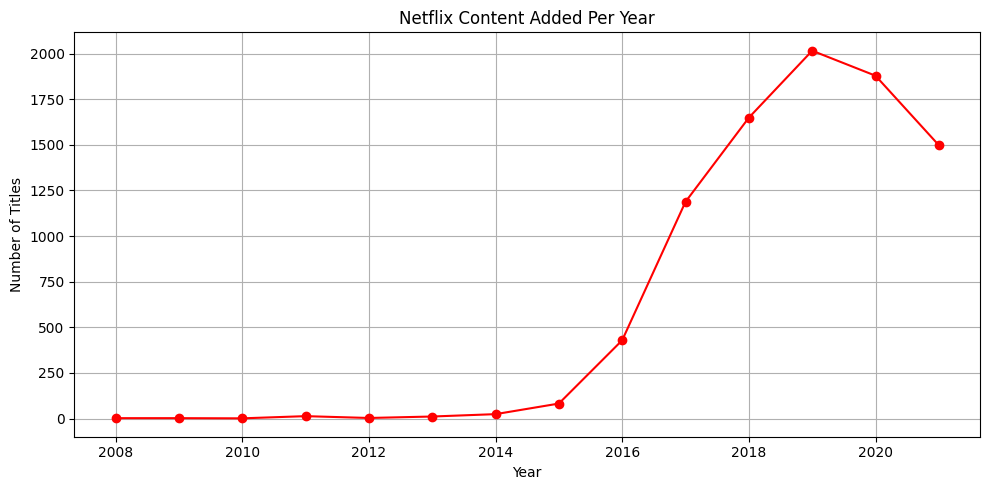

In [9]:
import matplotlib.pyplot as plt

# Convert date_added to datetime and extract year
netflix["date_added"] = pd.to_datetime(netflix["date_added"].str.strip(), errors="coerce")
netflix["year_added"] = netflix["date_added"].dt.year

# Count content added per year (2008-2021 to match GDP)
content_per_year = netflix[netflix["year_added"].between(2008, 2021)]["year_added"].value_counts().sort_index()
print("Content added per year:")
print(content_per_year)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(content_per_year.index, content_per_year.values, marker="o", color="red")
plt.title("Netflix Content Added Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.tight_layout()
plt.show()

**EDA – Movie vs TV Show Ratio Over Time**

Examines how the balance between Movies and TV Shows added to Netflix changed over time. A shift toward TV Shows during certain years could indicate a strategic response to viewer behavior during economic downturns.


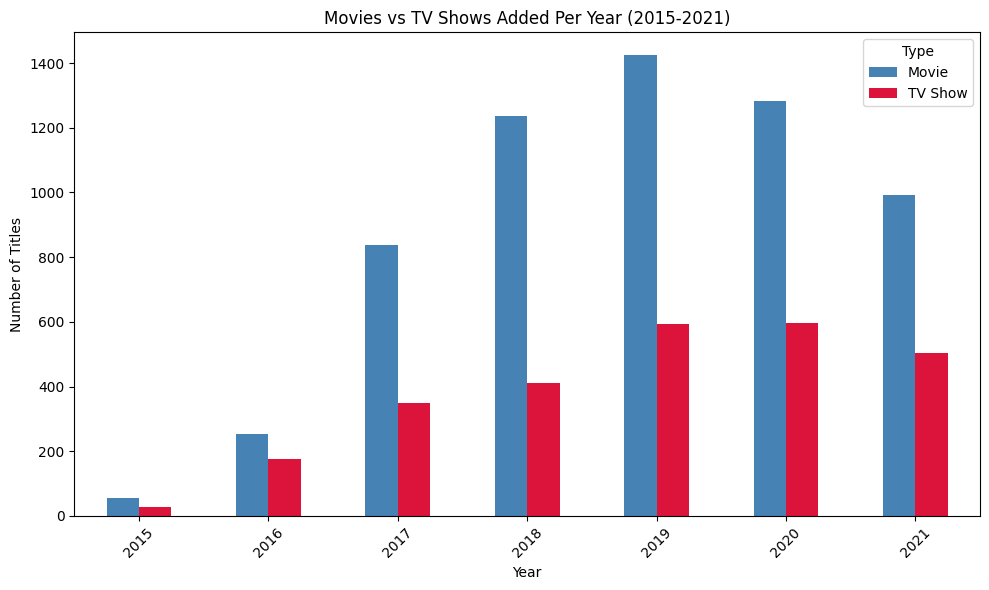

In [18]:
# Movie vs TV Show per year
type_year = netflix[netflix["year_added"].between(2015, 2021)].groupby(["year_added", "type"]).size().unstack()
type_year.index = type_year.index.astype(int)
type_year.plot(kind="bar", figsize=(10, 6), color=["steelblue", "crimson"])
plt.title("Movies vs TV Shows Added Per Year (2015-2021)")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.legend(title="Type")
plt.tight_layout()
plt.show()

**EDA – Top Genres on Netflix**

Analyzes the most common genres on Netflix. Since titles can have multiple genres, each genre is counted separately. Shows the top 15 genres by number of titles.

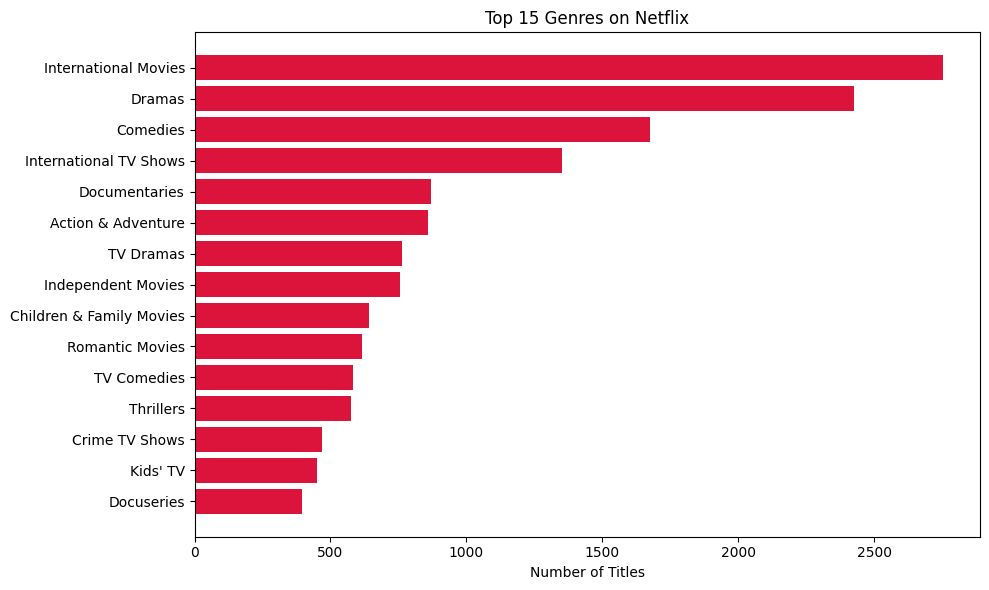

In [14]:
# Splits genres and count each one separately
from collections import Counter

all_genres = netflix["listed_in"].dropna().str.split(", ")
genre_counts = Counter([genre for sublist in all_genres for genre in sublist])
top_genres = pd.DataFrame(genre_counts.most_common(15), columns=["Genre", "Count"])

plt.figure(figsize=(10, 6))
plt.barh(top_genres["Genre"], top_genres["Count"], color="crimson")
plt.gca().invert_yaxis()
plt.xlabel("Number of Titles")
plt.title("Top 15 Genres on Netflix")
plt.tight_layout()
plt.show()

**EDA – Top 10 Countries by Number of Titles**

Shows which countries produce the most content on Netflix. Titles with multiple countries are counted for each country separately.

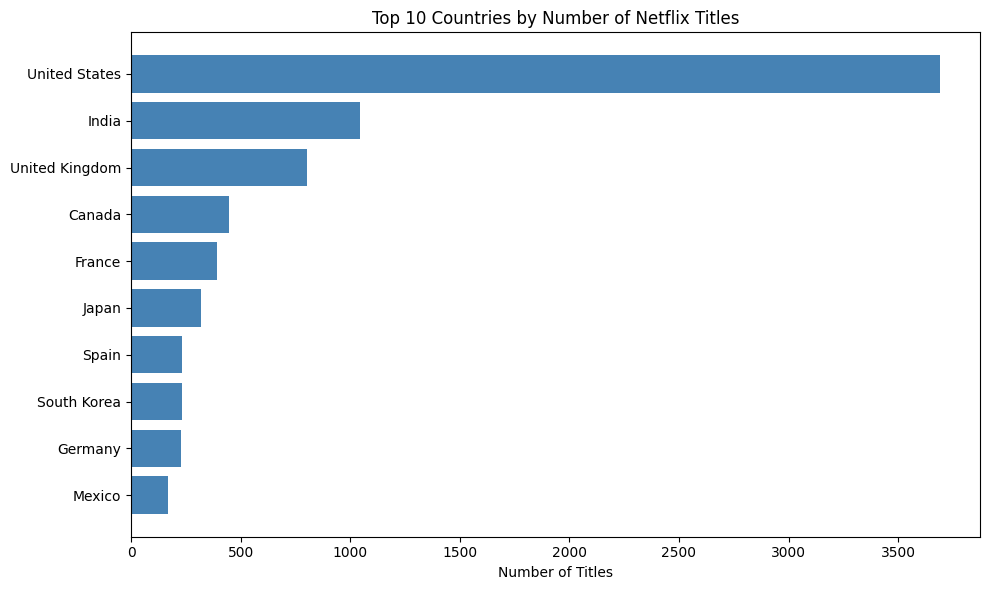

In [15]:
# Split countries and count
all_countries = netflix["country"].dropna().str.split(", ")
country_counts = Counter([c for sublist in all_countries for c in sublist])
top_countries = pd.DataFrame(country_counts.most_common(10), columns=["Country", "Count"])

plt.figure(figsize=(10, 6))
plt.barh(top_countries["Country"], top_countries["Count"], color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Number of Titles")
plt.title("Top 10 Countries by Number of Netflix Titles")
plt.tight_layout()
plt.show()

**EDA – Content Rating Distribution**

Shows the distribution of content ratings (e.g., TV-MA, TV-14, PG-13) across Netflix titles. Helps understand what audience demographics Netflix primarily targets.

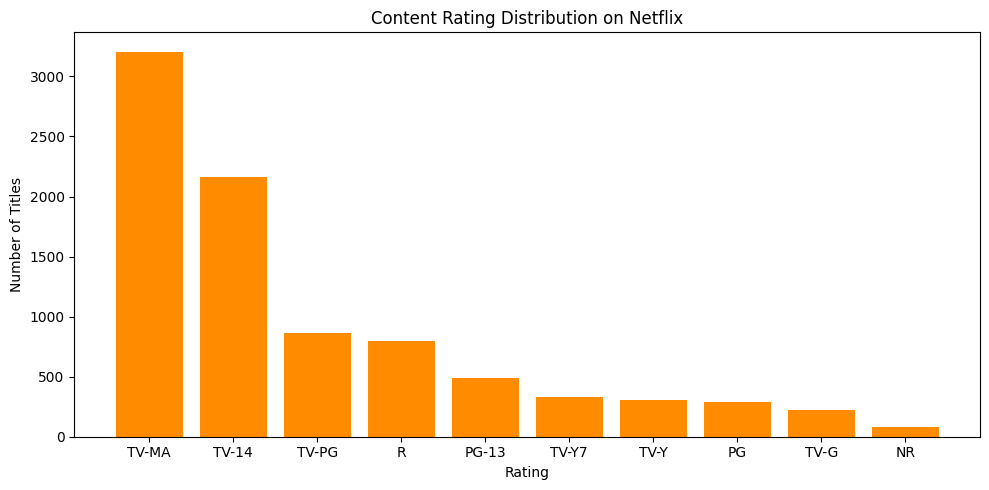

In [17]:
# Rating distribution
rating_counts = netflix["rating"].value_counts().dropna().head(10)

plt.figure(figsize=(10, 5))
plt.bar(rating_counts.index, rating_counts.values, color="darkorange")
plt.title("Content Rating Distribution on Netflix")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

**GDP EDA**

Extracts the global GDP growth rate from the World Bank dataset and plots it over time (2008–2021).

The dashed line marks 0% growth — dips below it indicate economic downturns (2009 financial crisis, 2020 COVID-19).

GDP data (2008-2021):
  year  gdp_growth
2008.0    2.092395
2009.0   -1.318649
2010.0    4.524240
2011.0    3.339003
2012.0    2.731210
2013.0    2.888142
2014.0    3.133017
2015.0    3.113789
2016.0    2.793592
2017.0    3.451830
2018.0    3.273958
2019.0    2.679118
2020.0   -2.899223
2021.0    6.413350


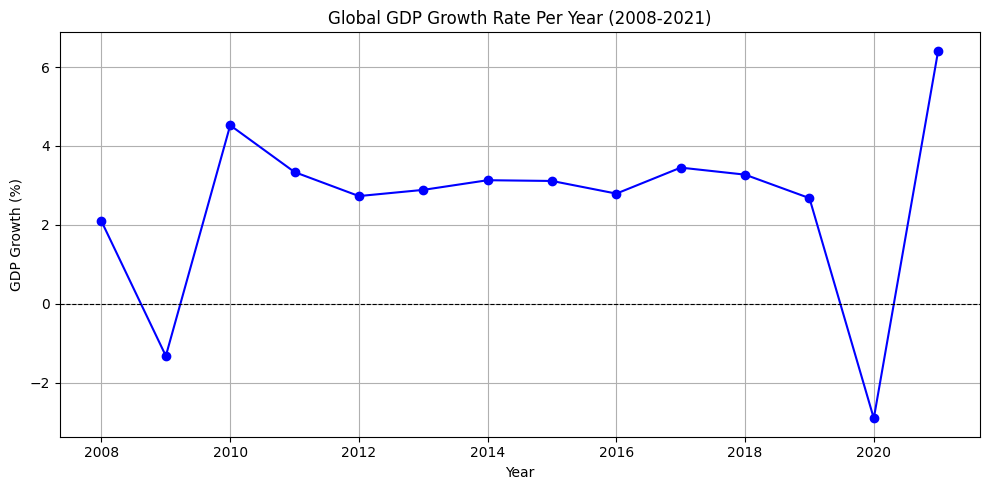

In [10]:
# Extract global GDP growth rate (World aggregate row)
gdp_global = gdp[gdp["Country Name"] == "World"][["Country Name"] + [str(y) for y in range(2008, 2022)]]

# Reshape from wide to long format
gdp_long = gdp_global.melt(id_vars="Country Name", var_name="year", value_name="gdp_growth")
gdp_long["year"] = gdp_long["year"].astype(float)

print("GDP data (2008-2021):")
print(gdp_long[["year", "gdp_growth"]].to_string(index=False))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(gdp_long["year"], gdp_long["gdp_growth"], marker="o", color="blue")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Global GDP Growth Rate Per Year (2008-2021)")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

**Merging Datasets & Visualization**

Merges the Netflix content count and global GDP growth rate by year.

Plots both on a dual-axis chart to visually compare Netflix growth and economic trends between 2008–2021.

  year  titles_added  gdp_growth
2008.0             2    2.092395
2009.0             2   -1.318649
2010.0             1    4.524240
2011.0            13    3.339003
2012.0             3    2.731210
2013.0            11    2.888142
2014.0            24    3.133017
2015.0            82    3.113789
2016.0           429    2.793592
2017.0          1188    3.451830
2018.0          1649    3.273958
2019.0          2016    2.679118
2020.0          1879   -2.899223
2021.0          1498    6.413350


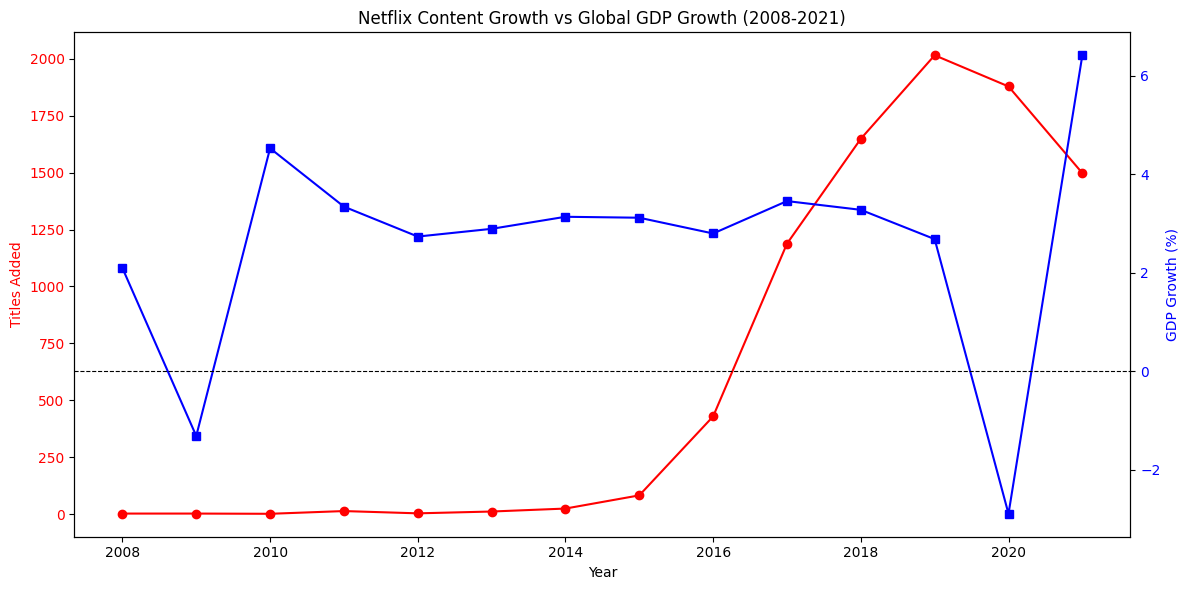

In [11]:
# Merge datasets
content_df = content_per_year.reset_index()
content_df.columns = ["year", "titles_added"]
content_df["year"] = content_df["year"].astype(float)

merged = pd.merge(content_df, gdp_long[["year", "gdp_growth"]], on="year")
print(merged.to_string(index=False))

# Plot both together
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel("Year")
ax1.set_ylabel("Titles Added", color="red")
ax1.plot(merged["year"], merged["titles_added"], marker="o", color="red", label="Netflix Titles")
ax1.tick_params(axis="y", labelcolor="red")

ax2 = ax1.twinx()
ax2.set_ylabel("GDP Growth (%)", color="blue")
ax2.plot(merged["year"], merged["gdp_growth"], marker="s", color="blue", label="GDP Growth")
ax2.tick_params(axis="y", labelcolor="blue")
ax2.axhline(0, color="black", linestyle="--", linewidth=0.8)

plt.title("Netflix Content Growth vs Global GDP Growth (2008-2021)")
fig.tight_layout()
plt.show()

**Hypothesis Testing**

Three hypothesis tests to investigate whether economic downturns affect Netflix's content strategy:

Test 1 – Pearson Correlation: Tests whether there is a statistically significant linear relationship between global GDP growth rate and the number of titles Netflix adds each year.

Test 2 – Independent T-test: Compares the average number of titles added during economic downturn years (GDP < 0) versus normal years. Downturn years in this dataset are 2009 and 2020.

Test 3 – Independent T-test: Tests whether Netflix shifts toward adding more TV Shows relative to Movies during economic downturns.

All tests use a significance level of 0.05.

In [20]:
from scipy import stats

# Hypothesis Test 1: Correlation between GDP growth and titles added
correlation, p_value = stats.pearsonr(merged["gdp_growth"], merged["titles_added"])

print("=== Hypothesis Test 1 ===")
print("H0: There is NO correlation between GDP growth and Netflix content added")
print("Ha: There IS a correlation between GDP growth and Netflix content added")
print()
print(f"Pearson Correlation: {correlation:.4f}")
print(f"P-value:             {p_value:.4f}")
print()
if p_value < 0.05:
    print("Result: REJECT H0 - significant correlation found")
else:
    print("Result: FAIL TO REJECT H0 - no significant correlation")

print()
print("=== Hypothesis Test 2 ===")
print("H0: Netflix adds the same amount of content during downturns vs normal years")
print("Ha: Netflix adds MORE content during economic downturns")
print()

# Define downturn years (GDP < 0)
downturn = merged[merged["gdp_growth"] < 0]["titles_added"]
normal = merged[merged["gdp_growth"] >= 0]["titles_added"]

print(f"Downturn years (GDP < 0): {merged[merged['gdp_growth'] < 0]['year'].tolist()}")
print(f"Average titles in downturn years: {downturn.mean():.1f}")
print(f"Average titles in normal years:   {normal.mean():.1f}")
print()

t_stat, p_val2 = stats.ttest_ind(downturn, normal)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_val2:.4f}")
print()
if p_val2 < 0.05:
    print("Result: REJECT H0 - Netflix significantly increases content during downturns")
else:
    print("Result: FAIL TO REJECT H0 - no significant difference found")
print()
# Calculate TV Show ratio per year
type_year_all = netflix[netflix["year_added"].between(2008, 2021)].groupby(["year_added", "type"]).size().unstack(fill_value=0)
type_year_all["tv_ratio"] = type_year_all["TV Show"] / (type_year_all["Movie"] + type_year_all["TV Show"])
type_year_all = type_year_all.reset_index()
type_year_all.columns.name = None
type_year_all["year_added"] = type_year_all["year_added"].astype(float)

merged3 = pd.merge(type_year_all[["year_added", "tv_ratio"]], merged[["year", "gdp_growth"]], left_on="year_added", right_on="year")

downturn_ratio = merged3[merged3["gdp_growth"] < 0]["tv_ratio"]
normal_ratio = merged3[merged3["gdp_growth"] >= 0]["tv_ratio"]

t_stat3, p_val3 = stats.ttest_ind(downturn_ratio, normal_ratio)

print("=== Hypothesis Test 3 ===")
print("H0: TV Show ratio is the same during downturns vs normal years")
print("Ha: Netflix adds relatively more TV Shows during economic downturns")
print()
print(f"Average TV Show ratio in downturn years: {downturn_ratio.mean():.3f}")
print(f"Average TV Show ratio in normal years:   {normal_ratio.mean():.3f}")
print()
print(f"T-statistic: {t_stat3:.4f}")
print(f"P-value:     {p_val3:.4f}")
print()
if p_val3 < 0.05:
    print("Result: REJECT H0 - Netflix shifts toward TV Shows during downturns")
else:
    print("Result: FAIL TO REJECT H0 - no significant shift found")

=== Hypothesis Test 1 ===
H0: There is NO correlation between GDP growth and Netflix content added
Ha: There IS a correlation between GDP growth and Netflix content added

Pearson Correlation: -0.0867
P-value:             0.7682

Result: FAIL TO REJECT H0 - no significant correlation

=== Hypothesis Test 2 ===
H0: Netflix adds the same amount of content during downturns vs normal years
Ha: Netflix adds MORE content during economic downturns

Downturn years (GDP < 0): [2009.0, 2020.0]
Average titles in downturn years: 940.5
Average titles in normal years:   576.3

T-statistic: 0.5697
P-value:     0.5794

Result: FAIL TO REJECT H0 - no significant difference found

=== Hypothesis Test 3 ===
H0: TV Show ratio is the same during downturns vs normal years
Ha: Netflix adds relatively more TV Shows during economic downturns

Average TV Show ratio in downturn years: 0.158
Average TV Show ratio in normal years:   0.255

T-statistic: -0.7095
P-value:     0.4916

Result: FAIL TO REJECT H0 - no si

**Box Plot – Titles Added: Normal vs Downturn Years**

Visually compares the distribution of Netflix titles added during normal years versus economic downturn years (2009 and 2020).
Complements Hypothesis Test 2.

Note: The median for normal years appears very low because Netflix had minimal content additions between 2008–2014. This wide spread reduces the statistical power of the t-test.

/tmp/ipykernel_5791/4031201665.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal.values, downturn.values],


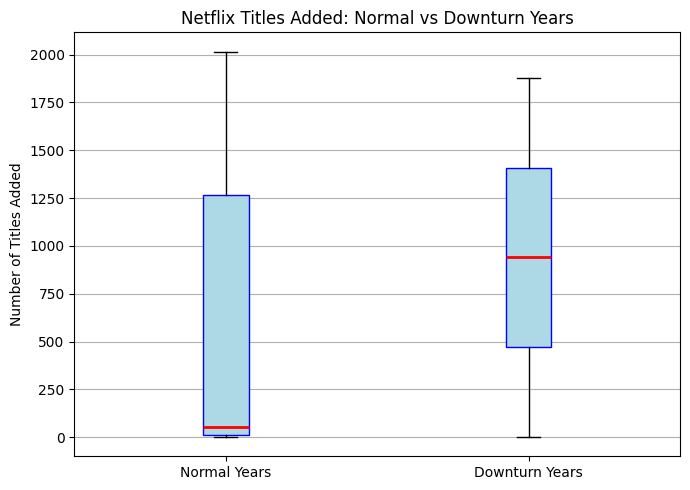

In [23]:
plt.figure(figsize=(7, 5))
plt.boxplot([normal.values, downturn.values],
            patch_artist=True,
            labels=["Normal Years", "Downturn Years"],
            boxprops=dict(facecolor="lightblue", color="blue"),
            medianprops=dict(color="red", linewidth=2))
plt.title("Netflix Titles Added: Normal vs Downturn Years")
plt.ylabel("Number of Titles Added")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

**Scatter Plot** – GDP Growth vs Titles Added

Plots each year as a point, with GDP growth rate on the x-axis and number of Netflix titles added on the y-axis. Each point is labeled with its year.

Visually confirms the lack of a clear linear relationship between the two variables.

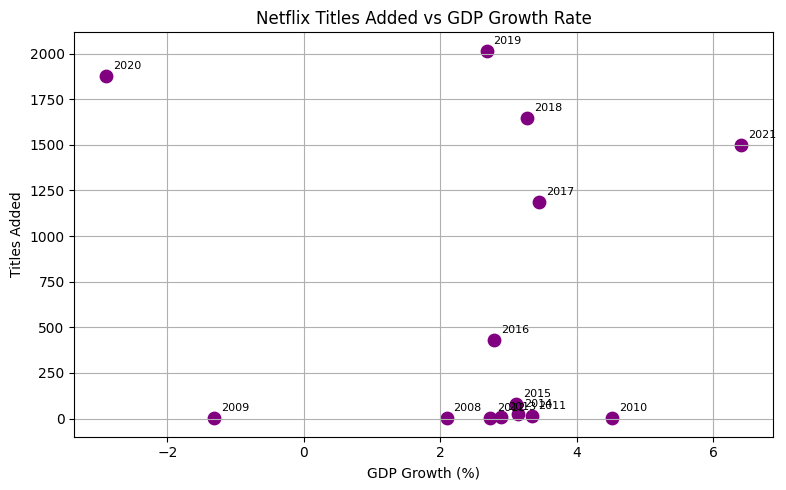

In [13]:
# Scatter plot: GDP growth vs titles added
plt.figure(figsize=(8, 5))
plt.scatter(merged["gdp_growth"], merged["titles_added"], color="purple", s=80)

for _, row in merged.iterrows():
    plt.annotate(int(row["year"]), (row["gdp_growth"], row["titles_added"]),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)

plt.xlabel("GDP Growth (%)")
plt.ylabel("Titles Added")
plt.title("Netflix Titles Added vs GDP Growth Rate")
plt.grid(True)
plt.tight_layout()
plt.show()

**ML – Linear Regression: Predicting Netflix Content Growth**

Applies linear regression to predict the number of titles Netflix adds per year based on global GDP growth rate. Although the hypothesis tests found no significant correlation, this model quantifies the relationship and evaluates prediction accuracy using RMSE and R² score. Leave-One-Out Cross Validation is used due to the small dataset size.

=== Linear Regression: GDP Growth → Netflix Titles Added ===
MSE:  1081129.43
RMSE: 1039.77
R²:   -0.7532


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


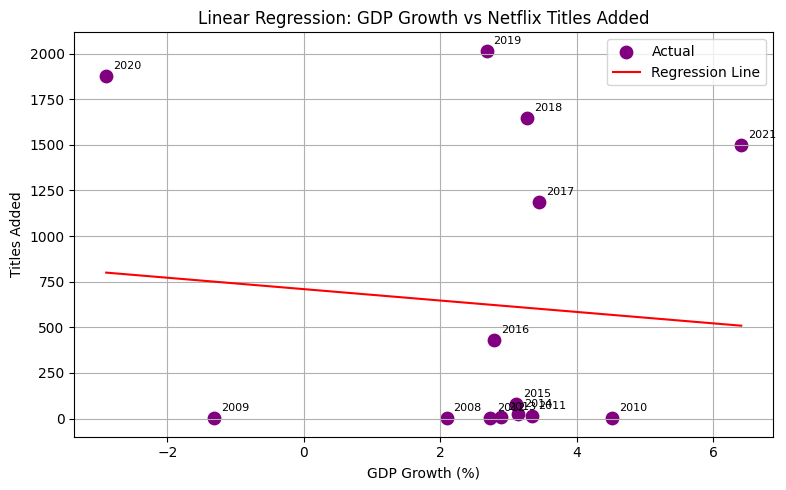

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = merged[["gdp_growth"]]
y = merged["titles_added"]

# Leave-One-Out Cross Validation (better for small datasets)
loo = LeaveOneOut()
predictions = []
actuals = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    model = LinearRegression()
    model.fit(X_train, y_train)
    predictions.append(model.predict(X_test)[0])
    actuals.append(y_test.values[0])

mse = mean_squared_error(actuals, predictions)
r2 = r2_score(actuals, predictions)

print("=== Linear Regression: GDP Growth → Netflix Titles Added ===")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {np.sqrt(mse):.2f}")
print(f"R²:   {r2:.4f}")

# Fit on full data for visualization
model_full = LinearRegression()
model_full.fit(X, y)

plt.figure(figsize=(8, 5))
plt.scatter(merged["gdp_growth"], merged["titles_added"], color="purple", s=80, label="Actual")
x_line = np.linspace(merged["gdp_growth"].min(), merged["gdp_growth"].max(), 100).reshape(-1, 1)
plt.plot(x_line, model_full.predict(x_line), color="red", label="Regression Line")
for _, row in merged.iterrows():
    plt.annotate(int(row["year"]), (row["gdp_growth"], row["titles_added"]),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.xlabel("GDP Growth (%)")
plt.ylabel("Titles Added")
plt.title("Linear Regression: GDP Growth vs Netflix Titles Added")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**ML – Random Forest Regression**

Applies Random Forest Regression to predict the number of Netflix titles added per year based on GDP growth rate. Random Forest builds multiple decision trees and averages their predictions, making it more robust than a single linear model. Leave-One-Out Cross Validation is used due to the small dataset size. Results are compared with the Linear Regression model.

=== Random Forest Regression: GDP Growth → Netflix Titles Added ===
MSE:  1418701.24
RMSE: 1191.09
R²:   -1.3006

=== Model Comparison ===
Linear Regression - RMSE: 1039.77, R²: -0.7532
Random Forest     - RMSE: 1191.09, R²: -1.3006


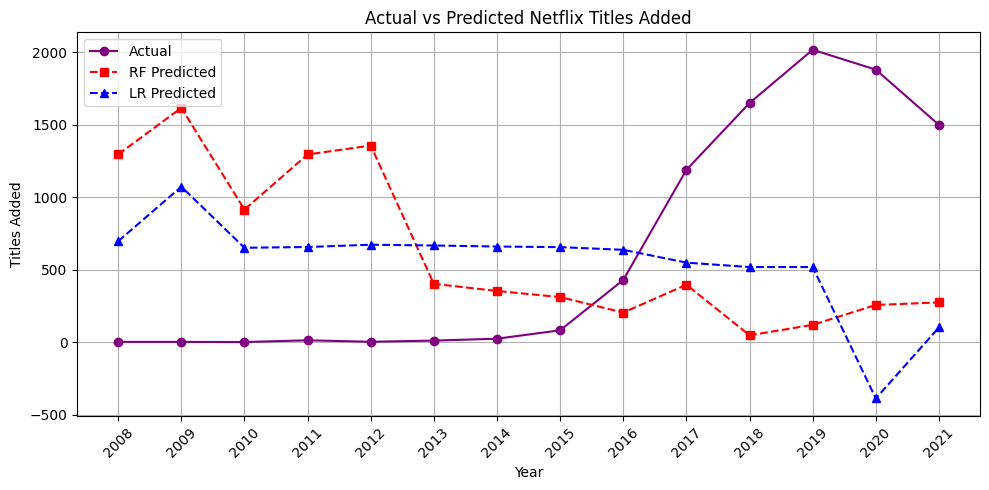

In [26]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Leave-One-Out Cross Validation
loo = LeaveOneOut()
rf_predictions = []
rf_actuals = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    rf_model.fit(X_train, y_train)
    rf_predictions.append(rf_model.predict(X_test)[0])
    rf_actuals.append(y_test.values[0])

rf_mse = mean_squared_error(rf_actuals, rf_predictions)
rf_r2 = r2_score(rf_actuals, rf_predictions)

print("=== Random Forest Regression: GDP Growth → Netflix Titles Added ===")
print(f"MSE:  {rf_mse:.2f}")
print(f"RMSE: {np.sqrt(rf_mse):.2f}")
print(f"R²:   {rf_r2:.4f}")
print()
print("=== Model Comparison ===")
print(f"Linear Regression - RMSE: {np.sqrt(mse):.2f}, R²: {r2:.4f}")
print(f"Random Forest     - RMSE: {np.sqrt(rf_mse):.2f}, R²: {rf_r2:.4f}")

plt.figure(figsize=(10, 5))
x_ax = range(len(rf_actuals))
plt.plot(x_ax, rf_actuals, marker="o", color="purple", label="Actual")
plt.plot(x_ax, rf_predictions, marker="s", color="red", linestyle="--", label="RF Predicted")
plt.plot(x_ax, predictions, marker="^", color="blue", linestyle="--", label="LR Predicted")
plt.xticks(x_ax, [int(y) for y in merged["year"]], rotation=45)
plt.xlabel("Year")
plt.ylabel("Titles Added")
plt.title("Actual vs Predicted Netflix Titles Added")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()